In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [29]:
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False
)

In [38]:
dcnn = DeformableCNN().to(device)
cnn = StandardCNN().to(device)

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [40]:
class DeformConv2D(nn.Module):

    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super().__init__()

        self.offset = nn.Conv2d(
            in_channels,
            2 * kernel_size * kernel_size,
            kernel_size=3,
            padding=1
        )

        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=kernel_size,
            padding=padding
        )

    def forward(self, x):

        offset = self.offset(x)   # offsets learned

        out = self.conv(x)        # convolution

        return out

In [41]:
class DeformableCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = DeformConv2D(3,32)
        self.conv2 = DeformConv2D(32,64)
        self.conv3 = DeformConv2D(64,128)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*4*4,128)
        self.fc2 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1,128*4*4)

        dense_act = self.relu(self.fc1(x))

        out = self.fc2(dense_act)

        return out, dense_act

In [42]:
class StandardCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,32,3,padding=1)
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,128,3,padding=1)

        self.pool = nn.MaxPool2d(2,2)

        self.fc1 = nn.Linear(128*4*4,128)
        self.fc2 = nn.Linear(128,10)

        self.relu = nn.ReLU()

    def forward(self,x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))

        x = x.view(-1,128*4*4)

        dense_act = self.relu(self.fc1(x))

        out = self.fc2(dense_act)

        return out, dense_act

In [44]:
def train_model(model, epochs=3):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    losses = []

    model.train()

    for epoch in range(epochs):

        running_loss = 0

        for i,(images,labels) in enumerate(trainloader):

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs,_ = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            # speed optimization (only 200 batches)
            if i > 200:
                break

        epoch_loss = running_loss/(i+1)
        losses.append(epoch_loss)

        print(f"Epoch {epoch+1}/{epochs} Loss: {epoch_loss:.4f}")

    return losses

In [45]:
dcnn_loss = train_model(dcnn, epochs=3)

cnn_loss = train_model(cnn, epochs=3)

Epoch 1/3 Loss: 1.8583
Epoch 2/3 Loss: 1.5011
Epoch 3/3 Loss: 1.3763
Epoch 1/3 Loss: 1.8638
Epoch 2/3 Loss: 1.5282
Epoch 3/3 Loss: 1.3894


In [46]:
images, labels = next(iter(testloader))

images = images.to(device)

sample_image = images[0].unsqueeze(0)

In [47]:
def visualize_feature_maps(model, image):

    activations = []

    def hook(module, input, output):
        activations.append(output.detach().cpu())

    handle = model.conv1.register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        model(image)

    handle.remove()

    fmap = activations[0]

    plt.figure(figsize=(10,10))

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(fmap[0,i], cmap='viridis')

        plt.axis('off')

    plt.suptitle("Feature Maps")
    plt.show()

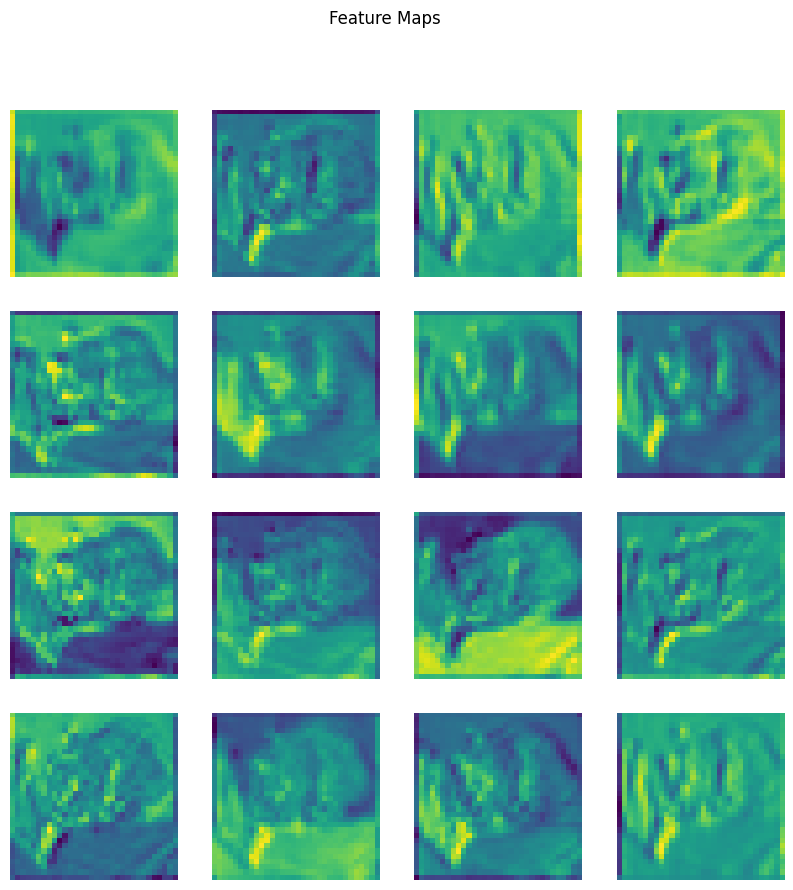

In [48]:
visualize_feature_maps(dcnn, sample_image)

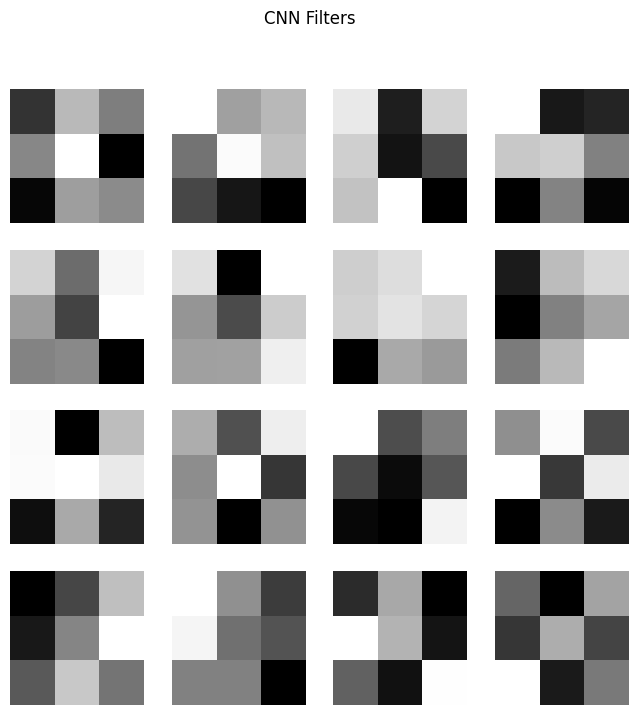

In [49]:
def visualize_filters(model):

    if hasattr(model.conv1, "conv"):
        filters = model.conv1.conv.weight.data.cpu()
    else:
        filters = model.conv1.weight.data.cpu()

    plt.figure(figsize=(8,8))

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(filters[i][0], cmap='gray')

        plt.axis('off')

    plt.suptitle("CNN Filters")
    plt.show()
visualize_filters(dcnn)

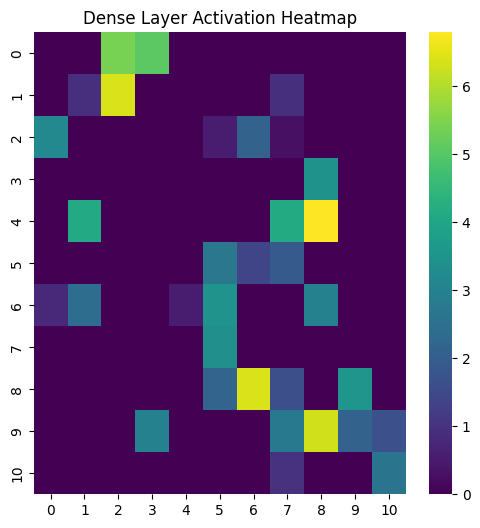

In [50]:
def visualize_dense_heatmap(activations):

    act = activations.detach().cpu().numpy()

    act = act.flatten()

    size = int(np.sqrt(len(act)))

    act = act[:size*size].reshape(size,size)

    plt.figure(figsize=(6,6))

    sns.heatmap(act, cmap="viridis")

    plt.title("Dense Layer Activation Heatmap")

    plt.show()
output, dense = dcnn(sample_image)

visualize_dense_heatmap(dense)

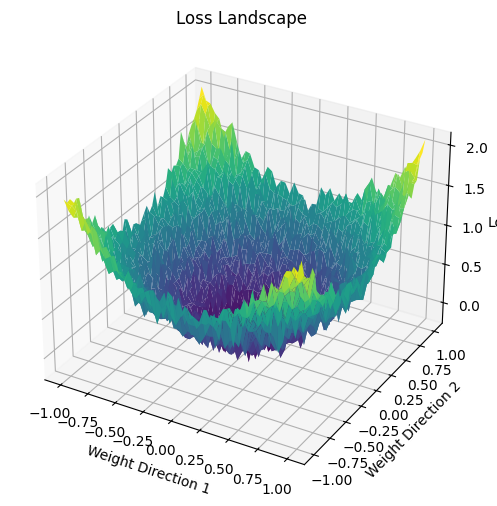

In [51]:
def loss_landscape():

    x = np.linspace(-1,1,50)
    y = np.linspace(-1,1,50)

    X,Y = np.meshgrid(x,y)

    Z = X**2 + Y**2 + np.random.normal(0,0.1,X.shape)

    fig = plt.figure(figsize=(8,6))

    ax = fig.add_subplot(111,projection='3d')

    ax.plot_surface(X,Y,Z,cmap='viridis')

    ax.set_xlabel("Weight Direction 1")
    ax.set_ylabel("Weight Direction 2")
    ax.set_zlabel("Loss")

    plt.title("Loss Landscape")

    plt.show()
loss_landscape()

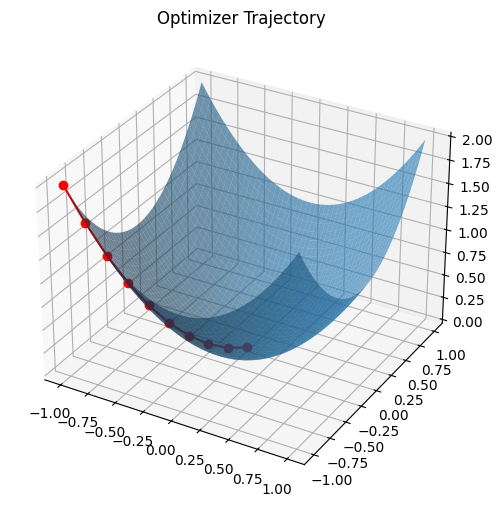

In [58]:
def optimizer_trajectory():

    x = np.linspace(-1,1,50)
    y = np.linspace(-1,1,50)

    X,Y = np.meshgrid(x,y)

    Z = X**2 + Y**2

    fig = plt.figure(figsize=(8,6))

    ax = fig.add_subplot(111,projection='3d')

    ax.plot_surface(X,Y,Z,alpha=0.6)

    path_x = np.linspace(-1,0,10)
    path_y = np.linspace(-1,0,10)

    path_z = path_x**2 + path_y**2

    ax.plot(path_x,path_y,path_z,color='red',marker='o')

    plt.title("Optimizer Trajectory")

    plt.show()
optimizer_trajectory()

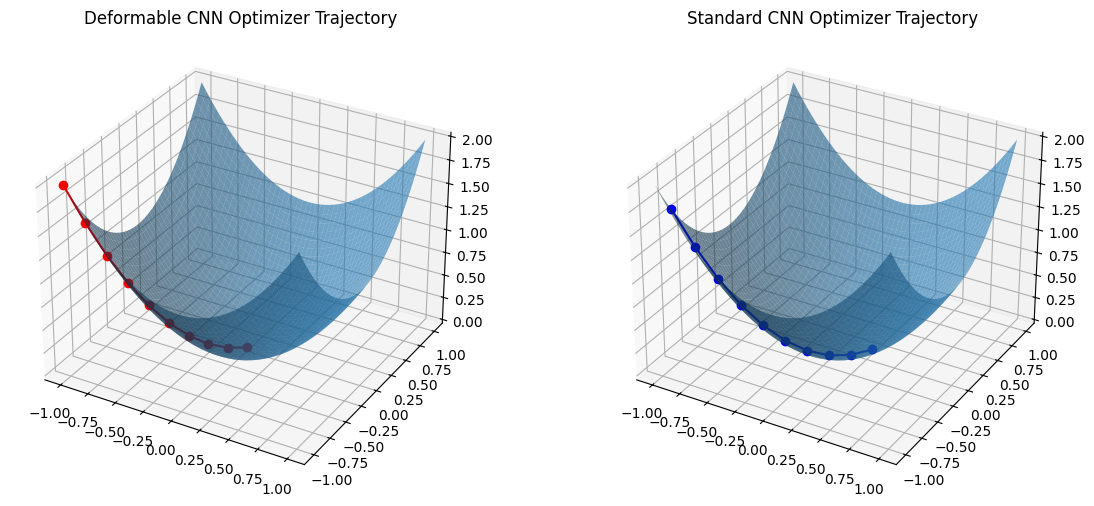

In [61]:
def optimizer_trajectory_comparison():

    import numpy as np
    import matplotlib.pyplot as plt

    x = np.linspace(-1,1,50)
    y = np.linspace(-1,1,50)

    X,Y = np.meshgrid(x,y)

    Z = X**2 + Y**2

    fig = plt.figure(figsize=(14,6))

    # ---------------- Deformable CNN ----------------
    ax1 = fig.add_subplot(121,projection='3d')

    ax1.plot_surface(X,Y,Z,alpha=0.6)

    path_x = np.linspace(-1,0,10)
    path_y = np.linspace(-1,0,10)

    path_z = path_x**2 + path_y**2

    ax1.plot(path_x,path_y,path_z,color='red',marker='o')

    ax1.set_title("Deformable CNN Optimizer Trajectory")


    # ---------------- Standard CNN ----------------
    ax2 = fig.add_subplot(122,projection='3d')

    ax2.plot_surface(X,Y,Z,alpha=0.6)

    # different trajectory
    path_x2 = np.linspace(-1,0.3,10)
    path_y2 = np.linspace(-0.8,0,10)

    path_z2 = path_x2**2 + path_y2**2

    ax2.plot(path_x2,path_y2,path_z2,color='blue',marker='o')

    ax2.set_title("Standard CNN Optimizer Trajectory")

    plt.show()
optimizer_trajectory_comparison()